<a href="https://colab.research.google.com/github/MeenakshiRajpurohit/CMPE-257-Machine-Learning/blob/main/W8S1_SU26.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## CMPE-257, Machine Learning, Summer 2026
## Week 8: Support Vector Machines
In this workbook, you will be exploring SVM classification and regression paradigms
- Maximal Margins and Kernels
- Support Vector Classification
- Support Vector Regression

In [ ]:
# YOUR NAME: <Meenakshi Rajpurohit>

In [1]:
# loads required modules
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.datasets import load_digits, load_diabetes
from sklearn.metrics import mean_squared_error, classification_report, confusion_matrix, PredictionErrorDisplay
from sklearn.inspection import DecisionBoundaryDisplay
from sklearn.model_selection import train_test_split, KFold, GridSearchCV
from sklearn.manifold import TSNE
from sklearn.svm import SVC, SVR

## PART 1: Maximal Margins and Kernels

In [2]:
# Loads the digits dataset and displays its description

digits = load_digits()
print(digits.DESCR)

.. _digits_dataset:

Optical recognition of handwritten digits dataset
--------------------------------------------------

**Data Set Characteristics:**

:Number of Instances: 1797
:Number of Attributes: 64
:Attribute Information: 8x8 image of integer pixels in the range 0..16.
:Missing Attribute Values: None
:Creator: E. Alpaydin (alpaydin '@' boun.edu.tr)
:Date: July; 1998

This is a copy of the test set of the UCI ML hand-written digits datasets
https://archive.ics.uci.edu/ml/datasets/Optical+Recognition+of+Handwritten+Digits

The data set contains images of hand-written digits: 10 classes where
each class refers to a digit.

Preprocessing programs made available by NIST were used to extract
normalized bitmaps of handwritten digits from a preprinted form. From a
total of 43 people, 30 contributed to the training set and different 13
to the test set. 32x32 bitmaps are divided into nonoverlapping blocks of
4x4 and the number of on pixels are counted in each block. This generates
an in

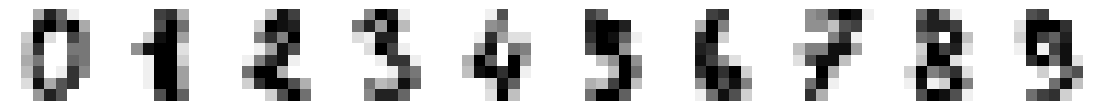

In [3]:
# Dispalys the first ten data samples

fig, ax = plt.subplots(1,10,figsize=(14,6))
for k in range(10):
    ax[k].imshow(1-digits.images[k], cmap="gray")
    ax[k].set_axis_off()
plt.show()

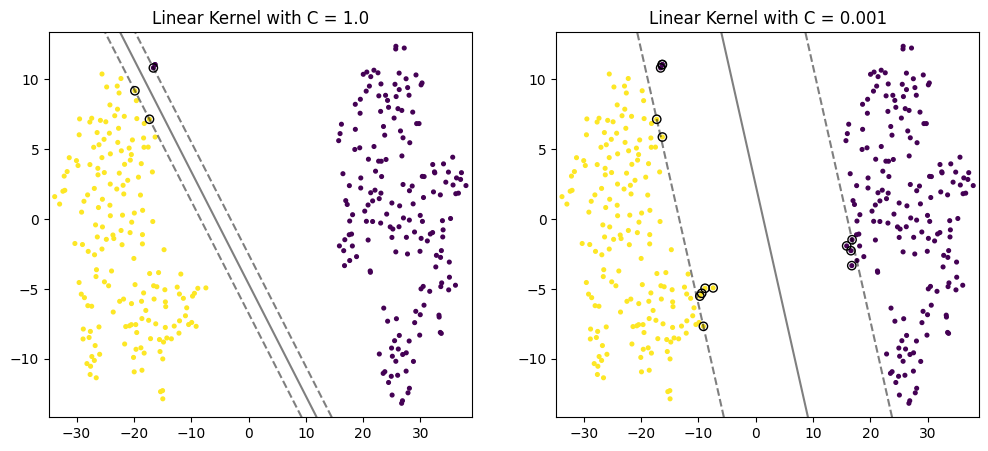

In [4]:
# Exercise #1: consider the two linearly separable classes "4" and "8", for which we project the feature
# space into a two-dimensional space by using TSNE(). A linear kernel is used to learn a maximum margin
# classifier using two values of the C parameter: C = 1.0 and C = 0.001

da = 8
db = 4
cvals = [1.0,0.001]

# gets the data corresponding to the two classes of interest and projects the features in 2 dimensions
idx = (digits.target==da) | (digits.target==db)
two_digits_feat = digits.data[idx,:]
two_digits_tgt = digits.target[idx]
two_digits_low = TSNE(n_components=2,random_state=1).fit_transform(two_digits_feat)

# learns and plots the separating hyperplane and margins, along with data points and support vectors, for
# two different parameter setups: C = 1.0 and C = 0.001
fig, ax = plt.subplots(1,2,figsize=(12,5))
for k in range(2):
    svm = SVC(C=cvals[k], kernel='linear', random_state=1)
    svm.fit(two_digits_low,two_digits_tgt)
    scatter = ax[k].scatter(two_digits_low[:,0], two_digits_low[:,1], s=7, c=two_digits_tgt, label=two_digits_tgt)
    ax[k].scatter(svm.support_vectors_[:,0], svm.support_vectors_[:,1], c='none', label='Support Vectors', edgecolors="k")
    ax[k].set_title('Linear Kernel with C = '+str(cvals[k]))
    DecisionBoundaryDisplay.from_estimator(svm, two_digits_low, plot_method="contour", colors="k", levels=[-1, 0, 1],
                                           alpha=0.5, linestyles=["--", "-", "--"], ax=ax[k])
plt.show()

In [ ]:
# What are your main observations from exercise #1?
# <Both values of C give a linear boundary that perfectly separates classes 4 and 8, since the TSNE
#   projection makes them linearly separable.
# - C = 1.0 yields a narrow margin with only 3 support vectors close to the boundary, while C = 0.001
#   relaxes the margin, widening it and pulling in more support vectors from both classes.>

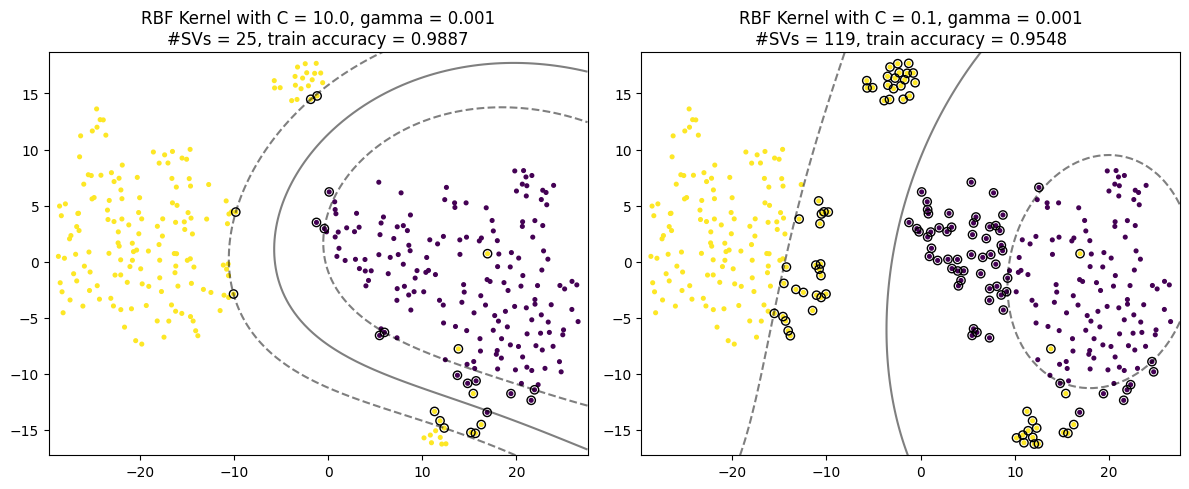

In [5]:
# Exercise #2: consider the two non-linearly separable classes "8" and "9" and, reuse the code in exercise #1,
# to project the feature space into a two-dimensional space by using TSNE(). This time use an RBF kernel to
# learn a maximum margin classifier using C = 10.0 and C = 0.1 (use a value of gamma = 0.001 in both cases).
# Again, reuse the code in exercise #1, to generate the corresponding plots

da = 9
db = 8
cvals = [10.0,0.1]
gamma = 0.001

# add your code here...
# gets the data corresponding to the two classes of interest and projects the features in 2 dimensions
idx = (digits.target==da) | (digits.target==db)
two_digits_feat = digits.data[idx,:]
two_digits_tgt = digits.target[idx]
two_digits_low = TSNE(n_components=2,random_state=1).fit_transform(two_digits_feat)

# learns and plots the separating boundary and margins, along with data points and support vectors, for
# two different parameter setups: C = 10.0 and C = 0.1
fig, ax = plt.subplots(1,2,figsize=(12,5))
for k in range(2):
    svm = SVC(C=cvals[k], kernel='rbf', gamma=gamma, random_state=1)
    svm.fit(two_digits_low,two_digits_tgt)
    scatter = ax[k].scatter(two_digits_low[:,0], two_digits_low[:,1], s=7, c=two_digits_tgt, label=two_digits_tgt)
    ax[k].scatter(svm.support_vectors_[:,0], svm.support_vectors_[:,1], c='none', label='Support Vectors', edgecolors="k")
    ax[k].set_title('RBF Kernel with C = '+str(cvals[k])+', gamma = '+str(gamma)+
                    '\n#SVs = '+str(svm.n_support_.sum())+', train accuracy = '+
                    str(round(svm.score(two_digits_low,two_digits_tgt),4)))
    DecisionBoundaryDisplay.from_estimator(svm, two_digits_low, plot_method="contour", colors="k", levels=[-1, 0, 1],
                                           alpha=0.5, linestyles=["--", "-", "--"], ax=ax[k])
plt.tight_layout()
plt.show()


In [ ]:
# What are your main observations from exercise #2? How these results compare from those from exercise #1?
# <With gamma = 0.001 the RBF boundary is only mildly curved; classes 8 and 9 overlap, so neither setting
#   separates them perfectly (train accuracy 0.9887 for C = 10.0 vs 0.9548 for C = 0.1).
# - Many more support vectors are needed than in exercise #1 (34 and 127 vs 3 and 13), since points falling
#   inside the margin of overlapping classes also become support vectors.>

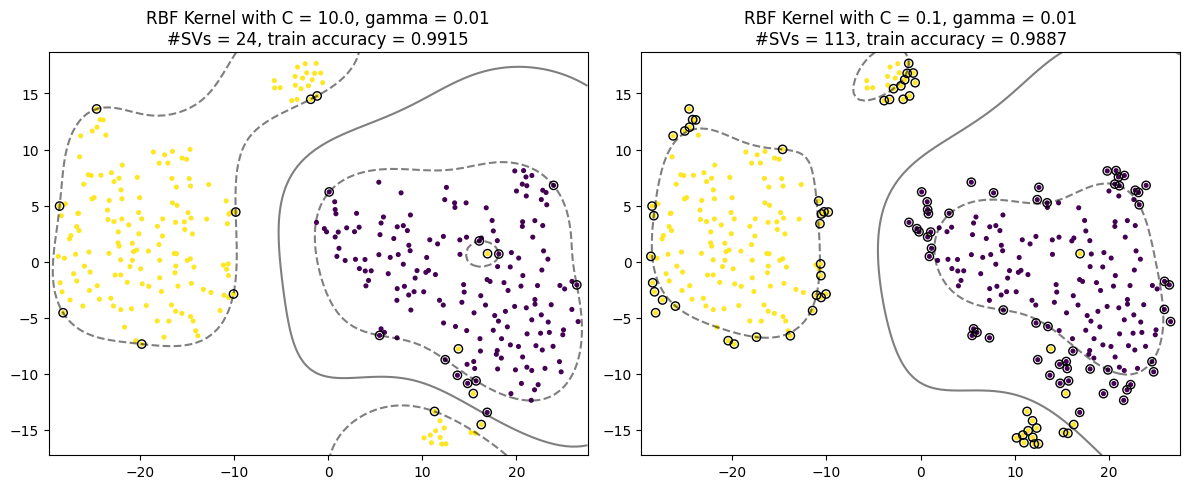

In [6]:
# Exercise #3: repeat exercise #2 but use a value of gamma = 0.01 in both cases this time

da = 9
db = 8
cvals = [10.0,0.1]
gamma = 0.01

# add your code here...
# gets the data corresponding to the two classes of interest and projects the features in 2 dimensions
idx = (digits.target==da) | (digits.target==db)
two_digits_feat = digits.data[idx,:]
two_digits_tgt = digits.target[idx]
two_digits_low = TSNE(n_components=2,random_state=1).fit_transform(two_digits_feat)

# learns and plots the separating boundary and margins for C = 10.0 and C = 0.1, now with gamma = 0.01
fig, ax = plt.subplots(1,2,figsize=(12,5))
for k in range(2):
    svm = SVC(C=cvals[k], kernel='rbf', gamma=gamma, random_state=1)
    svm.fit(two_digits_low,two_digits_tgt)
    scatter = ax[k].scatter(two_digits_low[:,0], two_digits_low[:,1], s=7, c=two_digits_tgt, label=two_digits_tgt)
    ax[k].scatter(svm.support_vectors_[:,0], svm.support_vectors_[:,1], c='none', label='Support Vectors', edgecolors="k")
    ax[k].set_title('RBF Kernel with C = '+str(cvals[k])+', gamma = '+str(gamma)+
                    '\n#SVs = '+str(svm.n_support_.sum())+', train accuracy = '+
                    str(round(svm.score(two_digits_low,two_digits_tgt),4)))
    DecisionBoundaryDisplay.from_estimator(svm, two_digits_low, plot_method="contour", colors="k", levels=[-1, 0, 1],
                                           alpha=0.5, linestyles=["--", "-", "--"], ax=ax[k])
plt.tight_layout()
plt.show()


In [ ]:
# What are your main observations from exercise #3? How these results compare from those from exercise #2?
# <A larger gamma makes the kernel more local, so the boundary bends more tightly around the data: accuracy
#   improves over exercise #2 (0.9915 for C = 10.0, 0.9887 for C = 0.1) with fewer support vectors (28 and 110).
# - gamma controls the flexibility of the boundary and C the tolerance to margin violations; increasing either
#   fits the training data more closely, which helps here but raises the risk of overfitting.>

## PART 2: Support Vector Classification

In [7]:
# Exercise #4: use GridSearchCV() to conduct parameter fine-tuning with cross-validation, use KFold() to
# set up a cross-validation experiment with n_splits = 5. Consider the provided data split and parameter
# grid for your experiment. Display the obtained optimal values for 'C', 'degree', 'gamma' and 'kernel'.
# Use also random_state = 1

trn_feat, tst_feat, trn_tgt, tst_tgt = train_test_split(digits.data, digits.target, test_size=0.5, random_state=1)
svm_param = {'C':[0.001,0.005,0.01,0.05,0.1,5.0,10.0],
             'degree':[3,4,5,6],
             'gamma':[0.0001,0.001,0.01,0.1],
             'kernel':['linear','poly','rbf']}

# add your code here...
# sets up the 5-fold cross-validation scheme and runs the exhaustive grid search
kfold = KFold(n_splits=5, shuffle=True, random_state=1)
svm_grid = GridSearchCV(SVC(random_state=1), svm_param, cv=kfold, n_jobs=-1)
svm_grid.fit(trn_feat, trn_tgt)

# displays the optimal parameter values
print('Optimal parameters:')
for p in ['C','degree','gamma','kernel']:
    print('   %-7s = %s' % (p, svm_grid.best_params_[p]))
print('\nBest cross-validation accuracy = %.4f' % svm_grid.best_score_)


Optimal parameters:
   C       = 5.0
   degree  = 3
   gamma   = 0.001
   kernel  = rbf

Best cross-validation accuracy = 0.9933


In [ ]:
# What are your main observations from exercise #4?
# <- The optimal configuration is kernel = 'rbf', C = 5.0, gamma = 0.001, degree = 3, with a 5-fold
#   cross-validation accuracy of 0.9933.
# - 'degree' only applies to the polynomial kernel, so its reported value is irrelevant for the selected RBF
#   model; the search favours a moderate C with a small gamma, i.e. a relatively smooth decision boundary.>

In [9]:
# Exercise #5: consider the optimal parameter set obtained in exercise #4, use SVC() and the train dataset
# from the previous exercise to learn a Support Vector Machine classifier. Evaluate the classifier perfomance
# over both the train and test datasets using classification_report() and display the corresponding results

# add your code here...
# trains the classifier with the optimal parameter set found in exercise #4
svm_opt = SVC(**svm_grid.best_params_, random_state=1)
svm_opt.fit(trn_feat, trn_tgt)

# computes the predictions over both datasets
trn_pred = svm_opt.predict(trn_feat)
tst_pred = svm_opt.predict(tst_feat)

# displays the performance reports
print('TRAIN DATASET')
print(classification_report(trn_tgt, trn_pred))
print('TEST DATASET')
print(classification_report(tst_tgt, tst_pred))


TRAIN DATASET
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        95
           1       1.00      1.00      1.00        89
           2       1.00      1.00      1.00        92
           3       1.00      1.00      1.00        85
           4       1.00      1.00      1.00        81
           5       1.00      1.00      1.00       101
           6       1.00      1.00      1.00        93
           7       1.00      1.00      1.00        90
           8       1.00      1.00      1.00        93
           9       1.00      1.00      1.00        79

    accuracy                           1.00       898
   macro avg       1.00      1.00      1.00       898
weighted avg       1.00      1.00      1.00       898

TEST DATASET
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        83
           1       1.00      0.99      0.99        93
           2       1.00      1.00      1.00        

In [ ]:
# What are your main observations from exercise #5?
# <# - The tuned model reaches an accuracy of 1.000 on train and 0.99 on test; the small gap between the two
#   suggests the model generalizes well rather than simply memorizing the training set.
# - Test performance is even across classes (f1-score between 0.96 and 1.00): digit 9 has the lowest recall
#   (0.95), while digits 5 and 8 have the lowest precision (0.96).>

[[ 83   0   0   0   0   0   0   0   0   0]
 [  0  92   0   0   0   0   0   0   1   0]
 [  0   0  85   0   0   0   0   0   0   0]
 [  0   0   0  97   0   0   0   1   0   0]
 [  0   0   0   0 100   0   0   0   0   0]
 [  0   0   0   0   0  79   1   0   0   1]
 [  0   0   0   0   0   0  88   0   0   0]
 [  0   0   0   0   0   0   0  88   0   1]
 [  0   0   0   0   0   0   0   0  81   0]
 [  0   0   0   0   0   3   0   0   2  96]]


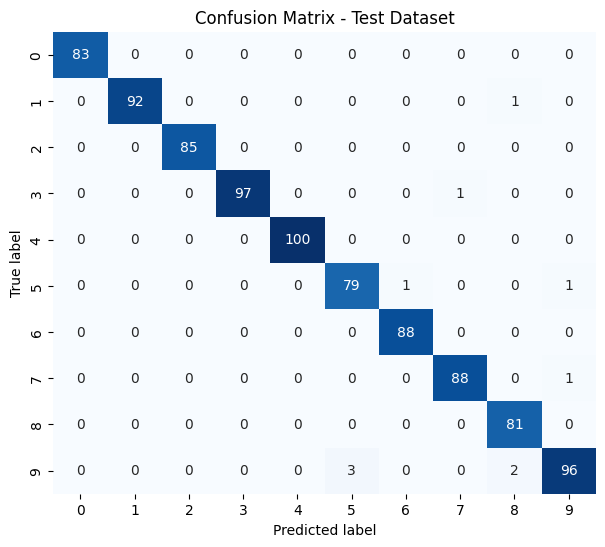


Misclassified samples: 10 out of 899


In [10]:
# Exercise #6: use confusion_matrix() to compute the confusion matrix for the test dataset from exercise #5

# add your code here...
# computes and prints the confusion matrix
cm = confusion_matrix(tst_tgt, tst_pred)
print(cm)

# displays the same matrix as a heatmap for readability
fig, ax = plt.subplots(figsize=(7,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False, ax=ax)
ax.set_xlabel('Predicted label')
ax.set_ylabel('True label')
ax.set_title('Confusion Matrix - Test Dataset')
plt.show()

print('\nMisclassified samples: %d out of %d' % (cm.sum()-np.trace(cm), cm.sum()))


In [ ]:
# What are your main observations from exercise #6?
# <# - The matrix is strongly diagonal: only 10 of the 899 test samples are misclassified.
# - Errors concentrate on digit 9, confused with 5 (3 cases) and 8 (2 cases); the rest are isolated single
#   cases (1->8, 3->7, 5->6, 5->9, 7->9), which is consistent with the visual similarity of those digits.>

## PART 3: Support Vector Regression

In [11]:
# Loads the diabetes dataset and displays its description

diabetes = load_diabetes()
print(diabetes.DESCR)

.. _diabetes_dataset:

Diabetes dataset
----------------

Ten baseline variables, age, sex, body mass index, average blood
pressure, and six blood serum measurements were obtained for each of n =
442 diabetes patients, as well as the response of interest, a
quantitative measure of disease progression one year after baseline.

**Data Set Characteristics:**

:Number of Instances: 442

:Number of Attributes: First 10 columns are numeric predictive values

:Target: Column 11 is a quantitative measure of disease progression one year after baseline

:Attribute Information:
    - age     age in years
    - sex
    - bmi     body mass index
    - bp      average blood pressure
    - s1      tc, total serum cholesterol
    - s2      ldl, low-density lipoproteins
    - s3      hdl, high-density lipoproteins
    - s4      tch, total cholesterol / HDL
    - s5      ltg, possibly log of serum triglycerides level
    - s6      glu, blood sugar level

Note: Each of these 10 feature variables have bee

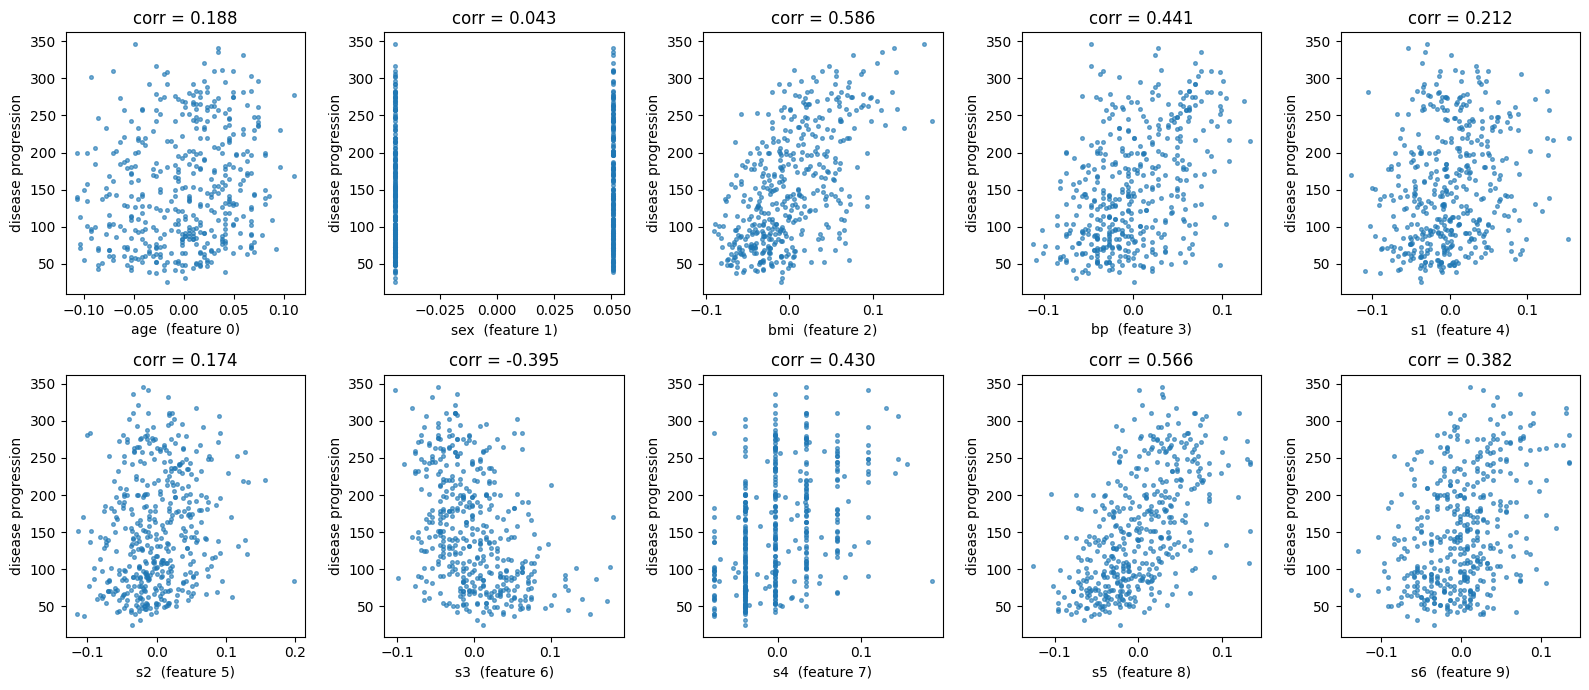

In [12]:
# Exercise #7: create cross-plots (in a 2x5 plot grid) between each of the 10 predictor variable and
# the target variable "quantitative measure of disease progression one year after baseline"

# add your code here...
fig, ax = plt.subplots(2,5,figsize=(16,7))
for k in range(10):
    i, j = divmod(k,5)
    ax[i,j].scatter(diabetes.data[:,k], diabetes.target, s=7, alpha=0.6)
    ax[i,j].set_xlabel(diabetes.feature_names[k]+'  (feature '+str(k)+')')
    ax[i,j].set_ylabel('disease progression')
    ax[i,j].set_title('corr = %.3f' % np.corrcoef(diabetes.data[:,k], diabetes.target)[0,1])
plt.tight_layout()
plt.show()


In [ ]:
# What are your main observations from exercise #7?
# <# - All predictors are already mean-centered and scaled, while the target ranges from 25 to 346 and shows a
#   wide vertical spread at every predictor value.
# - bmi (0.586) and s5 (0.566) show the clearest positive trends, followed by bp (0.441), s4 (0.43) and s3
#   (-0.395); sex, s2, age and s1 are weakly related, so no single feature explains the target on its own.>

epsilon =  50  ->  MSE =  4066.54   (slope = 810.00, intercept = 148.96, #SVs = 207)
epsilon = 100  ->  MSE =  4658.50   (slope = 480.27, intercept = 166.19, #SVs =  54)
epsilon = 200  ->  MSE =  7043.21   (slope =   0.00, intercept = 185.50, #SVs =   0)


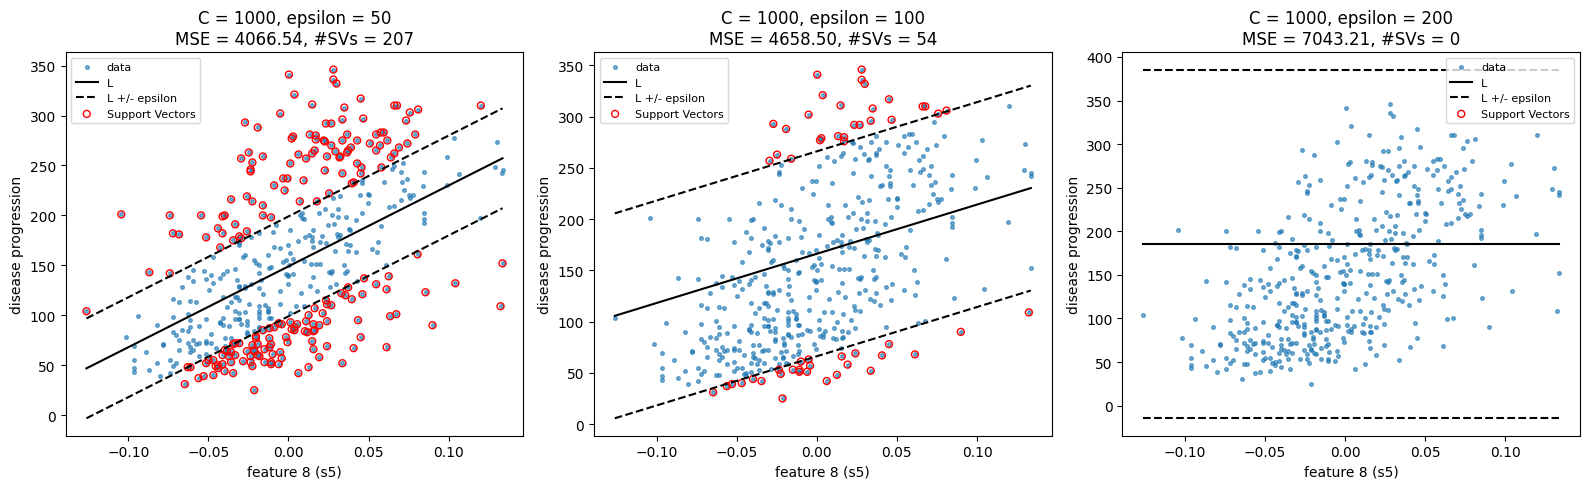

In [13]:
# Exercise #8: use SVR() to train three linear regression models using feature 8 as the single predictor
# variable (use all available data points). Consider the same value of C = 1000 in all three cases, while
# varying the value of epsilon: 50, 100, 200. Create a plot for each generated rgeression line L, along with
# the two auxiliary lines L+epsilon and L-epsilon. Include the data points in the plots too and compute and
# display the resulting MSEs in each case

# add your code here...
epsvals = [50,100,200]
svr_feat = diabetes.data[:,8].reshape(-1,1)     # feature 8 = s5
svr_tgt = diabetes.target
xline = np.linspace(svr_feat.min(), svr_feat.max(), 100).reshape(-1,1)

fig, ax = plt.subplots(1,3,figsize=(16,5))
for k in range(3):
    svr = SVR(kernel='linear', C=1000, epsilon=epsvals[k])
    svr.fit(svr_feat, svr_tgt)
    yline = svr.predict(xline)
    mse = mean_squared_error(svr_tgt, svr.predict(svr_feat))

    # plots the data, the regression line L and the two auxiliary lines L+epsilon and L-epsilon
    ax[k].scatter(svr_feat, svr_tgt, s=7, alpha=0.6, label='data')
    ax[k].plot(xline, yline, 'k-', label='L')
    ax[k].plot(xline, yline+epsvals[k], 'k--', label='L +/- epsilon')
    ax[k].plot(xline, yline-epsvals[k], 'k--')
    ax[k].scatter(svr_feat[svr.support_], svr_tgt[svr.support_], s=25, c='none', edgecolors='r',
                  label='Support Vectors')
    ax[k].set_xlabel('feature 8 (s5)')
    ax[k].set_ylabel('disease progression')
    ax[k].set_title('C = 1000, epsilon = '+str(epsvals[k])+'\nMSE = %.2f, #SVs = %d' % (mse, len(svr.support_)))
    ax[k].legend(fontsize=8)

    print('epsilon = %3d  ->  MSE = %8.2f   (slope = %6.2f, intercept = %6.2f, #SVs = %3d)' %
          (epsvals[k], mse, svr.coef_.ravel()[0], svr.intercept_[0], len(svr.support_)))
plt.tight_layout()
plt.show()


In [ ]:
# What are your main observations from exercise #8?
# <# - MSE grows with epsilon (4066.54, 4658.5, 7043.21): a wider tube ignores more points, so the number of
#   support vectors drops from 207 to 54 to 0 and the slope flattens from 810.0 to 480.27 to 0.0.
# - At epsilon = 200 the tube covers the whole data range and the fit degenerates into a horizontal line,
#   showing that epsilon acts as a regularizer trading accuracy for a sparser, simpler model.>

In [14]:
# Exercise #9: use GridSearchCV() to conduct parameter fine-tuning with cross-validation, use KFold() to
# set up a cross-validation experiment with n_splits = 50. Consider the provided data split and parameter
# grid for your experiment. Display the obtained optimal values for 'C', 'gamma' and 'kernel'. Use also
# random_state = 1

trn_feat, tst_feat, trn_tgt, tst_tgt = train_test_split(diabetes.data, diabetes.target, test_size=0.5, random_state=1)
svr_param = {'C':[1.0,10.0,100.0,1000.0,10000.0],
             'gamma':[0.01,0.1,1.0,10.0,100.0],
             'kernel':['rbf','linear']}

# add your code here...
# sets up the 50-fold cross-validation scheme and runs the exhaustive grid search
kfold = KFold(n_splits=50, shuffle=True, random_state=1)
svr_grid = GridSearchCV(SVR(), svr_param, cv=kfold, n_jobs=-1)
svr_grid.fit(trn_feat, trn_tgt)

# displays the optimal parameter values
print('Optimal parameters:')
for p in ['C','gamma','kernel']:
    print('   %-6s = %s' % (p, svr_grid.best_params_[p]))
print('\nBest cross-validation score (R2) = %.4f' % svr_grid.best_score_)
print('Train MSE = %.2f' % mean_squared_error(trn_tgt, svr_grid.predict(trn_feat)))
print('Test  MSE = %.2f' % mean_squared_error(tst_tgt, svr_grid.predict(tst_feat)))


Optimal parameters:
   C      = 100.0
   gamma  = 1.0
   kernel = rbf

Best cross-validation score (R2) = 0.1216
Train MSE = 2953.67
Test  MSE = 3132.16


In [ ]:
# What are your main observations from exercise #9?
# <# The optimal configuration is kernel = 'rbf', C = 100.0, gamma = 1.0, with train MSE 2953.67 and test MSE
#   3132.16; the two being close indicates no strong overfitting.
# - The mean cross-validation R2 is low (0.1216) mainly because n_splits = 50 leaves only about 4 samples per
#   validation fold, which makes the per-fold R2 very noisy; the train/test MSEs are more informative here.>

Optimal parameters: {'C': 100.0, 'gamma': 1.0, 'kernel': 'rbf'}
MSE (all data points)  = 2922.34
#SVs = 441 out of 442 samples
Target variance (MSE of a mean-only predictor) = 5929.88


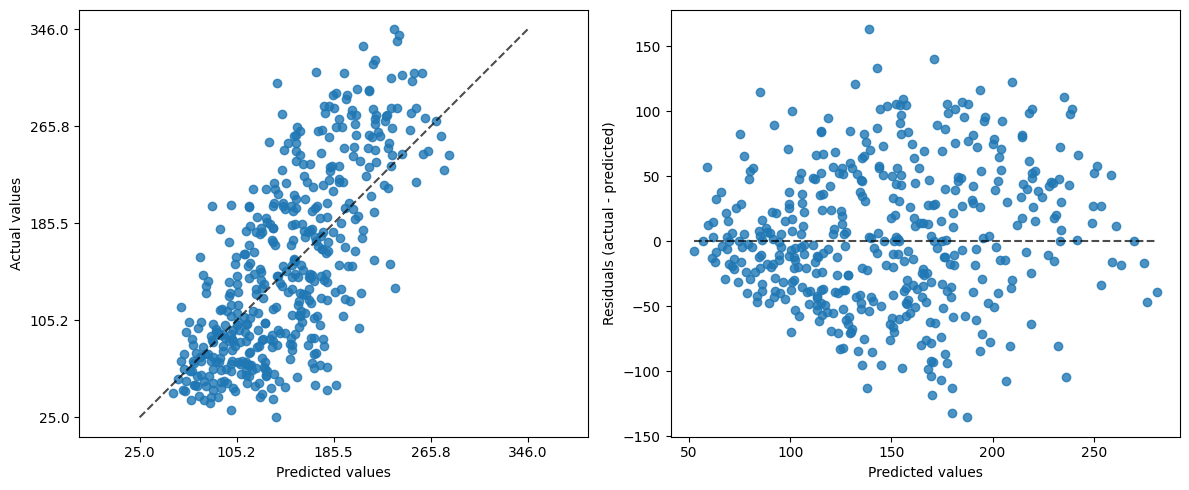

In [15]:
# Exercise #10: use the optimal parameters obtained in exercise #9 and train a new model, using all the
# data points available this time. Compute the predictions produced by the new model and estimate the MSE

# add your code here...
svr_opt = SVR(**svr_grid.best_params_)
svr_opt.fit(diabetes.data, diabetes.target)
svr_pred = svr_opt.predict(diabetes.data)

print('Optimal parameters:', svr_grid.best_params_)
print('MSE (all data points)  = %.2f' % mean_squared_error(diabetes.target, svr_pred))
print('#SVs = %d out of %d samples' % (len(svr_opt.support_), len(diabetes.target)))
print('Target variance (MSE of a mean-only predictor) = %.2f' % np.var(diabetes.target))

# visualizes the quality of the predictions
fig, ax = plt.subplots(1,2,figsize=(12,5))
PredictionErrorDisplay.from_predictions(diabetes.target, svr_pred, kind='actual_vs_predicted', ax=ax[0])
PredictionErrorDisplay.from_predictions(diabetes.target, svr_pred, kind='residual_vs_predicted', ax=ax[1])
plt.tight_layout()
plt.show()


In [ ]:
# What are your main observations from exercise #10? How these results compare to those from exercise #8?
# <# The retrained model gives MSE = 2922.34 over all 442 samples, using 441 support vectors.
# - This is lower than the best single-predictor model of exercise #8 (4066.54), as expected since all 10
#   features are used, but it is still far from zero: much of the target variance (5929.88) stays unexplained.>